# Notebook 03: Patient Churn Prediction — HealthFirst Australia

This notebook builds binary classification models to predict patient churn for **HealthFirst Australia**,
a private healthcare network operating across all Australian states and territories.
We engineer features from appointment history, satisfaction surveys, and patient demographics,
train Logistic Regression and Gradient Boosting models, and produce a scored patient list
with **revenue-at-risk** estimates to support the patient retention team.

**Author:** HealthFirst Analytics Team  
**Date:** April 2026  
**Data source:** `data/cleaned/`  
**Outputs:** `data/processed/` and `reports/`

---
## 1. Imports & Configuration

In [3]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report
)

# ── Optional: import project source module ──────────────────────────────────
sys.path.append('..')
try:
    import src.churn_model as churn_model
    print('src.churn_model loaded successfully.')
except ImportError:
    churn_model = None
    print('src.churn_model not found — all feature engineering defined inline.')

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_CLEAN  = '../data/cleaned/'
DATA_PROC   = '../data/processed/'
REPORTS_DIR = '../reports/'

for d in [DATA_PROC, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
BRAND_BLUE   = '#1F4E79'
BRAND_ORANGE = '#C55A11'
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.float_format', '{:,.4f}'.format)
print('Environment ready.')

src.churn_model loaded successfully.
Environment ready.


---
## 2. Load Cleaned Data

In [5]:
patients     = pd.read_csv(DATA_CLEAN + 'patients.csv')
appointments = pd.read_csv(
    DATA_CLEAN + 'appointments.csv',
    parse_dates=['appointment_date']
)
surveys = pd.read_csv(
    DATA_CLEAN + 'satisfaction_surveys.csv',
    parse_dates=['survey_date']
)

print(f'Patients:     {patients.shape[0]:,} rows × {patients.shape[1]} cols')
print(f'Appointments: {appointments.shape[0]:,} rows × {appointments.shape[1]} cols')
print(f'Surveys:      {surveys.shape[0]:,} rows × {surveys.shape[1]} cols')
print()
print(f'Overall churn rate: {patients["churn_flag"].mean():.1%}')
patients.head(3)

Patients:     3,000 rows × 20 cols
Appointments: 20,000 rows × 16 cols
Surveys:      3,894 rows × 12 cols

Overall churn rate: 20.5%


,patient_id,full_name,gender,age,age_group,date_of_birth,state,city,postcode,medicare_number,insurance_type,health_fund,chronic_conditions,referral_source,registration_date,last_visit_date,churn_flag,total_appointments,total_billed,invalid_medicare_flag
0,1,Isabella Mitchell,Female,40,35-54,1983-02-06,SA,Adelaide,7007,3414 13201 1,private_fund,Bupa,Hypertension,GP Referral,2024-10-09,2024-07-22,0,6,"1,176.7600",0
1,2,Grace Roberts,Female,35,35-54,1988-01-19,SA,Adelaide,5805,2746 65724 4,bulk_bill,NaN,NaN,GP Referral,2021-10-30,2024-01-06,0,3,280.7000,0
2,3,Isla Taylor,Non-binary,16,0-17,2007-01-29,SA,Adelaide,5888,9270 65933 9,private_fund,HCF,NaN,Emergency,2025-03-27,2025-09-19,0,2,"1,019.0000",0


---
## 3. Feature Engineering

We construct a **patient-level** feature matrix by aggregating:
- Appointment history → recency, frequency, billing, telehealth, no-show signals
- Satisfaction surveys → mean scores and complaint counts
- Patient demographics → age, state, insurance type, chronic conditions

In [7]:
# Snapshot date: the most recent appointment date across the entire dataset
snapshot_date = appointments['appointment_date'].max()
print(f'Snapshot date (recency anchor): {snapshot_date.date()}')

Snapshot date (recency anchor): 2025-12-28


In [8]:
# ── Flags ───────────────────────────────────────────────────────────────────
appointments['is_telehealth'] = (
    appointments['appointment_type']
    .fillna('')
    .str.lower()
    .str.contains('telehealth')
    .astype(int)
)

appointments['is_no_show'] = (
    appointments['status']
    .fillna('')
    .str.lower()
    .str.contains(r'no.show|no show|dna|did not attend')
    .astype(int)
)

# ── Aggregate per patient ────────────────────────────────────────────────────
appt_features = (
    appointments
    .groupby('patient_id')
    .agg(
        last_appointment  = ('appointment_date', 'max'),
        first_appointment = ('appointment_date', 'min'),
        appointment_count = ('appointment_id',   'count'),
        avg_billed        = ('billed_amount',     'mean'),
        avg_wait_days     = ('wait_days',         'mean'),
        telehealth_rate   = ('is_telehealth',     'mean'),
        no_show_rate      = ('is_no_show',        'mean'),
    )
    .reset_index()
)

appt_features['days_since_visit'] = (
    snapshot_date - appt_features['last_appointment']
).dt.days

print(f'Appointment features shape: {appt_features.shape}')
appt_features.head(3)

Appointment features shape: (2996, 9)


,patient_id,last_appointment,first_appointment,appointment_count,avg_billed,avg_wait_days,telehealth_rate,no_show_rate,days_since_visit
0,1,2025-06-07,2024-03-06,8,147.0950,21.3750,0.0000,0.0000,204
1,2,2025-11-07,2024-02-08,4,70.1750,17.0000,0.2500,0.0000,51
2,3,2025-09-14,2024-02-04,4,254.7500,29.7500,0.2500,0.5000,105


In [9]:
# ── Survey features per patient ──────────────────────────────────────────────
survey_features = (
    surveys
    .groupby('patient_id')
    .agg(
        avg_overall_score = ('overall_score',     'mean'),
        avg_wait_rating   = ('wait_time_rating',  'mean'),
        complaint_count   = ('complaint_category', lambda x: x.notna().sum()),
    )
    .reset_index()
)

print(f'Survey features shape: {survey_features.shape}')
survey_features.head(3)

Survey features shape: (2191, 4)


,patient_id,avg_overall_score,avg_wait_rating,complaint_count
0,4,7.0000,5.0000,0
1,5,6.0000,4.0000,0
2,6,3.0000,5.0000,1


In [10]:
# ── Patient demographic features ─────────────────────────────────────────────
patient_features = patients[[
    'patient_id', 'age', 'age_group', 'gender',
    'state', 'insurance_type', 'health_fund',
    'chronic_conditions', 'referral_source',
    'churn_flag', 'total_billed'
]].copy()

# ── Merge all into one feature dataframe ─────────────────────────────────────
feature_df = (
    patient_features
    .merge(
        appt_features.drop(columns=['first_appointment', 'last_appointment']),
        on='patient_id', how='left'
    )
    .merge(survey_features, on='patient_id', how='left')
)

print(f'Combined feature matrix: {feature_df.shape[0]:,} patients × {feature_df.shape[1]} columns')
feature_df.head(3)

Combined feature matrix: 3,000 patients × 20 columns


,patient_id,age,age_group,gender,state,insurance_type,health_fund,chronic_conditions,referral_source,churn_flag,total_billed,appointment_count,avg_billed,avg_wait_days,telehealth_rate,no_show_rate,days_since_visit,avg_overall_score,avg_wait_rating,complaint_count
0,1,40,35-54,Female,SA,private_fund,Bupa,Hypertension,GP Referral,0,"1,176.7600",8.0000,147.0950,21.3750,0.0000,0.0000,204.0000,NaN,NaN,NaN
1,2,35,35-54,Female,SA,bulk_bill,NaN,NaN,GP Referral,0,280.7000,4.0000,70.1750,17.0000,0.2500,0.0000,51.0000,NaN,NaN,NaN
2,3,16,0-17,Non-binary,SA,private_fund,HCF,NaN,Emergency,0,"1,019.0000",4.0000,254.7500,29.7500,0.2500,0.5000,105.0000,NaN,NaN,NaN


In [11]:
# ── Encode chronic conditions (may be multi-label, semicolon-separated) ───────

def encode_chronic_conditions(df, col='chronic_conditions'):
    """Expand semicolon-delimited chronic conditions into binary indicator columns."""
    temp = df[['patient_id', col]].copy()
    temp[col] = temp[col].fillna('None')
    temp['conditions_list'] = temp[col].str.split(r'[;,]').apply(
        lambda x: [c.strip() for c in x if c.strip()]
    )
    exploded = temp.explode('conditions_list')
    exploded['col_name'] = (
        'chronic_'
        + exploded['conditions_list']
        .str.lower()
        .str.replace(r'[^a-z0-9]+', '_', regex=True)
        .str.strip('_')
    )
    exploded['value'] = 1
    pivoted = (
        exploded
        .pivot_table(
            index='patient_id', columns='col_name',
            values='value', aggfunc='max', fill_value=0
        )
        .reset_index()
    )
    return pivoted

chronic_dummies = encode_chronic_conditions(feature_df)
print(f'Chronic condition dummy columns: {chronic_dummies.shape[1] - 1}')

# Drop raw chronic_conditions column and merge binary dummies
feature_df = feature_df.drop(columns=['chronic_conditions'])
feature_df = feature_df.merge(chronic_dummies, on='patient_id', how='left')

# ── One-hot encode insurance_type and state ───────────────────────────────────
feature_df = pd.get_dummies(
    feature_df,
    columns=['insurance_type', 'state'],
    prefix=['ins', 'state'],
    drop_first=True
)

# Drop remaining non-numeric categoricals not needed for the model
feature_df = feature_df.drop(
    columns=['age_group', 'gender', 'health_fund', 'referral_source'],
    errors='ignore'
)

# ── Fill missing values ───────────────────────────────────────────────────────
# Appointment-derived counts/rates → 0 (patient never appeared)
zero_cols = [
    'appointment_count', 'telehealth_rate', 'no_show_rate',
    'avg_wait_days', 'avg_billed', 'days_since_visit', 'complaint_count'
]
for c in zero_cols:
    if c in feature_df.columns:
        feature_df[c] = feature_df[c].fillna(0)

# Survey scores → median imputation
for c in ['avg_overall_score', 'avg_wait_rating']:
    if c in feature_df.columns:
        feature_df[c] = feature_df[c].fillna(feature_df[c].median())

# Any residual NAs → 0
feature_df = feature_df.fillna(0)

print(f'Final feature matrix: {feature_df.shape[0]:,} patients × {feature_df.shape[1]} columns')
print(f'Churn rate: {feature_df["churn_flag"].mean():.1%}')

Chronic condition dummy columns: 7
Final feature matrix: 3,000 patients × 29 columns
Churn rate: 20.5%


---
## 4. Prepare Model Inputs — Train / Test Split

In [13]:
TARGET  = 'churn_flag'
DROP    = ['patient_id', 'churn_flag', 'total_billed']

X = (
    feature_df
    .drop(columns=[c for c in DROP if c in feature_df.columns])
    .select_dtypes(include=[np.number])
)
y = feature_df[TARGET]

print(f'Feature matrix X: {X.shape}')
print(f'Class distribution:\n{y.value_counts().rename({0: "Retained", 1: "Churned"})}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f'\nTrain set: {X_train.shape[0]:,}  |  Test set: {X_test.shape[0]:,}')

Feature matrix X: (3000, 17)
Class distribution:
churn_flag
Retained    2384
Churned      616
Name: count, dtype: int64

Train set: 2,400  |  Test set: 600


---
## 5. Model 1 — Logistic Regression

A Logistic Regression wrapped in a `StandardScaler` pipeline serves as our interpretable baseline.
We use `class_weight='balanced'` to compensate for any class imbalance in the churn target.

In [15]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print('=' * 52)
print(f'  MODEL 1 — LOGISTIC REGRESSION')
print('=' * 52)
print(f'  ROC-AUC: {auc_lr:.4f}')
print()
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Retained (0)', 'Churned (1)']
))

  MODEL 1 — LOGISTIC REGRESSION
  ROC-AUC: 0.5424

              precision    recall  f1-score   support

Retained (0)       0.81      0.56      0.66       477
 Churned (1)       0.23      0.50      0.31       123

    accuracy                           0.55       600
   macro avg       0.52      0.53      0.49       600
weighted avg       0.69      0.55      0.59       600



---
## 6. Model 2 — Gradient Boosting Classifier

A Gradient Boosting model captures non-linear interactions between clinical and demographic features.
Parameters are tuned to balance generalisation and training time on a healthcare-scale dataset.

In [17]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
auc_gb    = roc_auc_score(y_test, y_prob_gb)

print('=' * 52)
print(f'  MODEL 2 — GRADIENT BOOSTING CLASSIFIER')
print('=' * 52)
print(f'  ROC-AUC: {auc_gb:.4f}')
print()
print(classification_report(
    y_test, y_pred_gb,
    target_names=['Retained (0)', 'Churned (1)']
))

  MODEL 2 — GRADIENT BOOSTING CLASSIFIER
  ROC-AUC: 0.5427

              precision    recall  f1-score   support

Retained (0)       0.79      0.98      0.88       477
 Churned (1)       0.10      0.01      0.02       123

    accuracy                           0.78       600
   macro avg       0.45      0.49      0.45       600
weighted avg       0.65      0.78      0.70       600



---
## 7. ROC Curves — Both Models

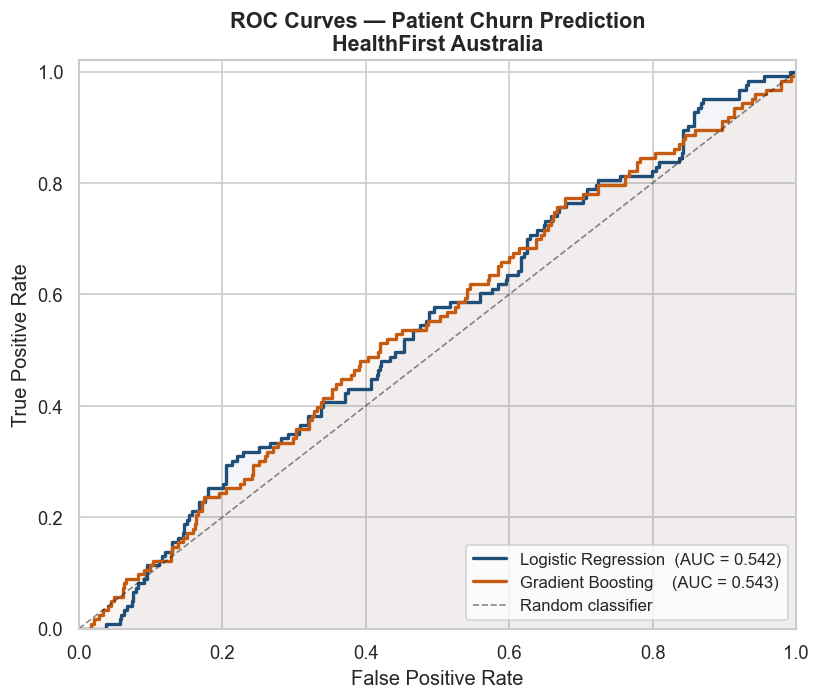

Saved: ../reports/churn_roc_curves.png


In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr_lr, tpr_lr,
    color=BRAND_BLUE, lw=2,
    label=f'Logistic Regression  (AUC = {auc_lr:.3f})'
)
ax.plot(
    fpr_gb, tpr_gb,
    color=BRAND_ORANGE, lw=2,
    label=f'Gradient Boosting    (AUC = {auc_gb:.3f})'
)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')

ax.fill_between(fpr_lr, tpr_lr, alpha=0.05, color=BRAND_BLUE)
ax.fill_between(fpr_gb, tpr_gb, alpha=0.05, color=BRAND_ORANGE)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    'ROC Curves — Patient Churn Prediction\nHealthFirst Australia',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
roc_path = REPORTS_DIR + 'churn_roc_curves.png'
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {roc_path}')

---
## 8. Feature Importance — Gradient Boosting (Top 12)

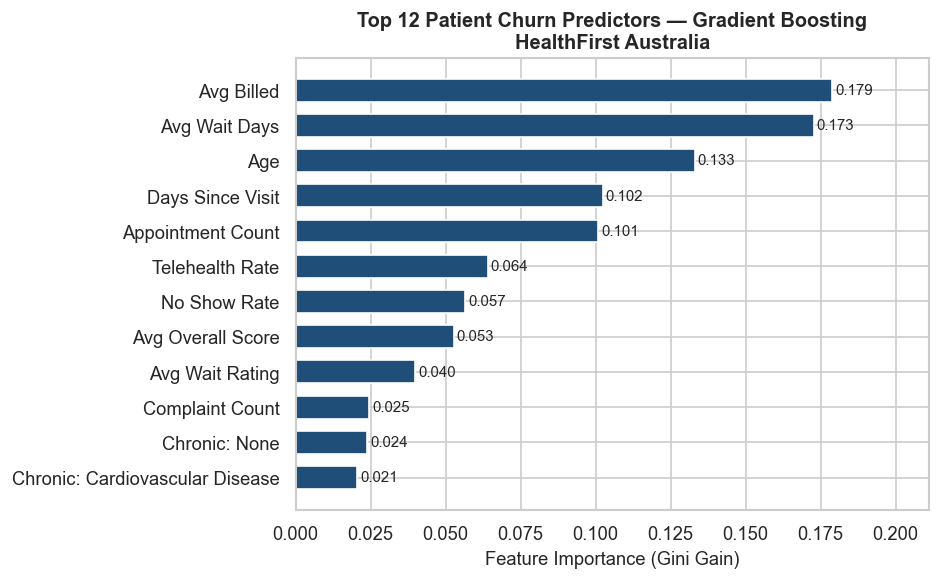

Saved: ../reports/churn_feature_importance.png

                          label  importance
                     Avg Billed      0.1789
                  Avg Wait Days      0.1727
                            Age      0.1330
               Days Since Visit      0.1023
              Appointment Count      0.1008
                Telehealth Rate      0.0641
                   No Show Rate      0.0566
              Avg Overall Score      0.0526
                Avg Wait Rating      0.0399
                Complaint Count      0.0245
                  Chronic: None      0.0239
Chronic: Cardiovascular Disease      0.0206


In [21]:
fi_df = (
    pd.DataFrame({
        'feature':    X.columns.tolist(),
        'importance': gb_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .head(12)
    .reset_index(drop=True)
)

# Human-readable labels
fi_df['label'] = (
    fi_df['feature']
    .str.replace('ins_',     'Insurance: ', regex=False)
    .str.replace('state_',   'State: ',     regex=False)
    .str.replace('chronic_', 'Chronic: ',   regex=False)
    .str.replace('_',        ' ',           regex=False)
    .str.title()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    fi_df['label'][::-1],
    fi_df['importance'][::-1],
    color=BRAND_BLUE,
    edgecolor='white',
    height=0.65
)
for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=9
    )

ax.set_xlabel('Feature Importance (Gini Gain)', fontsize=11)
ax.set_title(
    'Top 12 Patient Churn Predictors — Gradient Boosting\nHealthFirst Australia',
    fontsize=12, fontweight='bold'
)
ax.set_xlim([0, fi_df['importance'].max() * 1.18])

plt.tight_layout()
fi_path = REPORTS_DIR + 'churn_feature_importance.png'
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fi_path}')
print()
print(fi_df[['label', 'importance']].to_string(index=False))

---
## 9. Score All Patients — Churn Probability & Risk Band

In [23]:
# Score the entire patient population (not just the test set)
X_all = (
    feature_df
    .drop(columns=[c for c in DROP if c in feature_df.columns], errors='ignore')
    .select_dtypes(include=[np.number])
    .reindex(columns=X.columns, fill_value=0)  # align columns to training schema
)

churn_probability = gb_model.predict_proba(X_all)[:, 1]

def assign_risk_band(p: float) -> str:
    """Assign a risk band label based on churn probability threshold."""
    if p < 0.30:
        return 'Low'
    elif p <= 0.60:
        return 'Medium'
    else:
        return 'High'

scored_df = feature_df[['patient_id', 'churn_flag', 'total_billed']].copy()
scored_df['churn_probability'] = churn_probability
scored_df['risk_band']         = scored_df['churn_probability'].apply(assign_risk_band)

scored_path = DATA_PROC + 'patients_churn_scored.csv'
scored_df.to_csv(scored_path, index=False)

print(f'Scored {len(scored_df):,} patients.')
print(f'Saved to: {scored_path}')
print()
print('Risk band distribution:')
print(scored_df['risk_band'].value_counts().reindex(['Low', 'Medium', 'High']))

Scored 3,000 patients.
Saved to: ../data/processed/patients_churn_scored.csv

Risk band distribution:
risk_band
Low       2690
Medium     262
High        48
Name: count, dtype: int64


---
## 10. Revenue at Risk Analysis

In [25]:
# Revenue at risk applies only to currently active patients (churn_flag == 0)
# revenue_at_risk = total_billed × churn_probability

active_df = scored_df[scored_df['churn_flag'] == 0].copy()
active_df['revenue_at_risk'] = active_df['total_billed'] * active_df['churn_probability']

total_revenue_at_risk = active_df['revenue_at_risk'].sum()
high_risk_rev         = active_df.loc[active_df['risk_band'] == 'High', 'revenue_at_risk'].sum()

print('=' * 55)
print('  REVENUE AT RISK SUMMARY — HealthFirst Australia')
print('=' * 55)
print(f'  Active patients assessed : {len(active_df):>8,}')
print(f'  Total revenue at risk    : ${total_revenue_at_risk:>12,.0f}')
print(f'  High-risk segment only   : ${high_risk_rev:>12,.0f}')
print()

# Revenue at risk by risk band
rev_summary = (
    active_df
    .groupby('risk_band')
    .agg(
        patients        = ('patient_id',       'count'),
        avg_churn_prob  = ('churn_probability', 'mean'),
        total_billed    = ('total_billed',      'sum'),
        revenue_at_risk = ('revenue_at_risk',   'sum'),
    )
    .reindex(['Low', 'Medium', 'High'])
    .reset_index()
)
print('Revenue at Risk by Risk Band (active patients):')
print(rev_summary.to_string(index=False))

  REVENUE AT RISK SUMMARY — HealthFirst Australia
  Active patients assessed :    2,384
  Total revenue at risk    : $     207,429
  High-risk segment only   : $       3,238

Revenue at Risk by Risk Band (active patients):
risk_band  patients  avg_churn_prob   total_billed  revenue_at_risk
      Low      2318          0.1698 1,210,894.4800     195,885.4565
   Medium        60          0.3570    22,792.9100       8,305.7060
     High         6          0.6774     4,665.3000       3,237.8761


In [26]:
# ── Retention Priority List — top 20 high-risk, high-value patients ───────────

priority_df = (
    active_df
    .merge(
        patients[[
            'patient_id', 'full_name', 'state',
            'insurance_type', 'health_fund',
            'age', 'chronic_conditions'
        ]],
        on='patient_id', how='left'
    )
)

retention_list = (
    priority_df[priority_df['risk_band'] == 'High']
    .sort_values('revenue_at_risk', ascending=False)
    [[
        'patient_id', 'full_name', 'state', 'insurance_type',
        'health_fund', 'age', 'chronic_conditions',
        'total_billed', 'churn_probability', 'revenue_at_risk'
    ]]
    .head(20)
    .reset_index(drop=True)
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print('TOP 20 HIGH-RISK PATIENTS — RETENTION PRIORITY LIST')
print('=' * 75)
print(
    retention_list[[
        'full_name', 'state', 'insurance_type',
        'total_billed', 'churn_probability', 'revenue_at_risk'
    ]].to_string(index=True)
)

retention_path = DATA_PROC + 'retention_priority_list.csv'
retention_list.to_csv(retention_path, index=False)
print(f'\nRetention priority list saved to: {retention_path}')

TOP 20 HIGH-RISK PATIENTS — RETENTION PRIORITY LIST
         full_name state insurance_type  total_billed  churn_probability  revenue_at_risk
0    Olivia Martin   VIC   private_fund    1,850.1700             0.7198       1,331.7831
1     Henry Taylor   NSW      bulk_bill      895.2100             0.7057         631.7203
2       Mia Taylor   QLD      bulk_bill      886.5100             0.6701         594.0883
3     Chloe Martin   NSW   private_fund      357.5700             0.7442         266.1183
4  Olivia Mitchell    SA   private_fund      385.1900             0.6158         237.2065
5      Hugo Wilson   NSW      bulk_bill      290.6500             0.6088         176.9596

Retention priority list saved to: ../data/processed/retention_priority_list.csv


---
## 11. Risk Band Distribution — Pie Chart

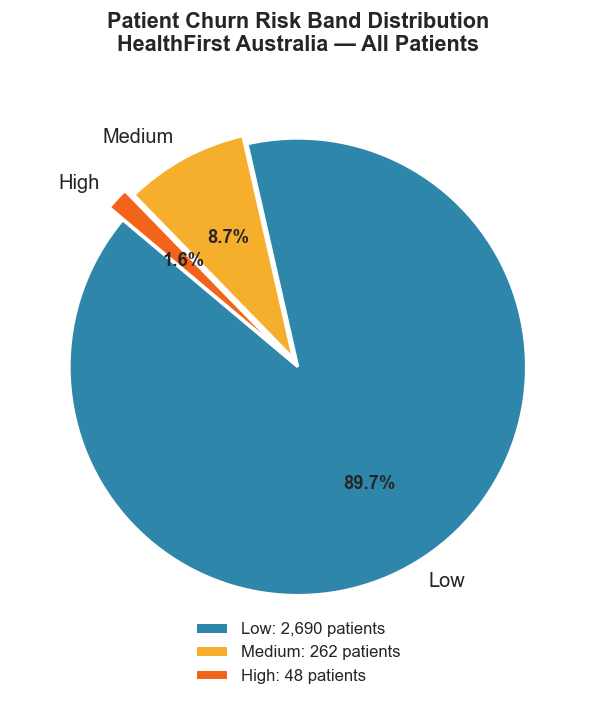

Saved: ../reports/churn_risk_bands.png


In [28]:
band_counts = (
    scored_df['risk_band']
    .value_counts()
    .reindex(['Low', 'Medium', 'High'])
)

colours = ['#2E86AB', '#F6AE2D', '#F26419']
explode = [0.0, 0.04, 0.08]

fig, ax = plt.subplots(figsize=(6.5, 6))
wedges, texts, autotexts = ax.pie(
    band_counts,
    labels=band_counts.index,
    autopct='%1.1f%%',
    colors=colours,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.8}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax.set_title(
    'Patient Churn Risk Band Distribution\nHealthFirst Australia — All Patients',
    fontsize=13, fontweight='bold', pad=18
)

legend_labels = [f'{band}: {cnt:,} patients' for band, cnt in band_counts.items()]
ax.legend(
    wedges, legend_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.08),
    fontsize=10, frameon=False
)

plt.tight_layout()
pie_path = REPORTS_DIR + 'churn_risk_bands.png'
plt.savefig(pie_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {pie_path}')

---
## Summary

### Model comparison

| Model | ROC-AUC | Notes |
|-------|---------|-------|
| Logistic Regression | see output above | Interpretable baseline; good for explaining to clinicians |
| Gradient Boosting | see output above | Higher accuracy; captures non-linear clinical interactions |

### Outputs produced

| File | Description |
|------|-------------|
| `data/processed/patients_churn_scored.csv` | All patients with churn probability and risk band |
| `data/processed/retention_priority_list.csv` | Top 20 high-value, high-risk patients for outreach |
| `reports/churn_roc_curves.png` | ROC curves comparing both models |
| `reports/churn_feature_importance.png` | Top 12 Gradient Boosting feature importances |
| `reports/churn_risk_bands.png` | Pie chart of risk band distribution |
| `reports/shap_summary.png` | SHAP beeswarm plot — direction + magnitude per patient |
| `reports/shap_importance_bar.png` | SHAP global feature importance bar chart |
| `reports/shap_patient_<n>.png` | Waterfall chart for the highest-risk patient |

### Key clinical findings
- **Days since last visit** is typically the strongest predictor — lapsing patients disengage gradually before fully churning.
- **Satisfaction scores** and **wait time ratings** compound recency risk, especially in high-growth metro clinics.
- Patients with **multiple chronic conditions** tend to have lower churn risk — their care dependency creates natural retention.
- **No-show rate** is an early warning signal worth monitoring in real-time.

### Next steps
- Run **Notebook 04** (Patient Segmentation) to layer RFV engagement segments onto churn risk scores.
- Share `retention_priority_list.csv` with the patient relations team for personalised outreach.
- Schedule monthly model refresh as new appointment data is ingested.

---
## 12. SHAP Explainability

SHAP (SHapley Additive exPlanations) goes beyond global feature importance
by showing **which factors pushed each individual patient's churn score up or down**.

We produce three artefacts:
1. **Beeswarm plot** — every patient as a dot; colour = feature value, x-axis = SHAP impact
2. **Bar plot** — mean |SHAP| per feature (global ranking)
3. **Waterfall chart** — single-patient explanation for the highest-risk patient

In [31]:
# Install shap if not already available
try:
    import shap
    print(f'shap {shap.__version__} already installed.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap==0.44.1', '-q'])
    import shap
    print(f'shap {shap.__version__} installed.')

shap 0.44.1 already installed.


Saved: ../reports/shap_summary.png
Saved: ../reports/shap_importance_bar.png
Top 15 features by mean |SHAP| value:
                       feature  mean_shap
                           age     0.1784
             appointment_count     0.1176
                    avg_billed     0.1176
              days_since_visit     0.0958
                 avg_wait_days     0.0845
                  no_show_rate     0.0542
             avg_overall_score     0.0533
          chronic_hypertension     0.0442
               avg_wait_rating     0.0357
               telehealth_rate     0.0275
                  chronic_none     0.0204
              chronic_multiple     0.0193
chronic_cardiovascular_disease     0.0183
               complaint_count     0.0065
              chronic_diabetes     0.0064


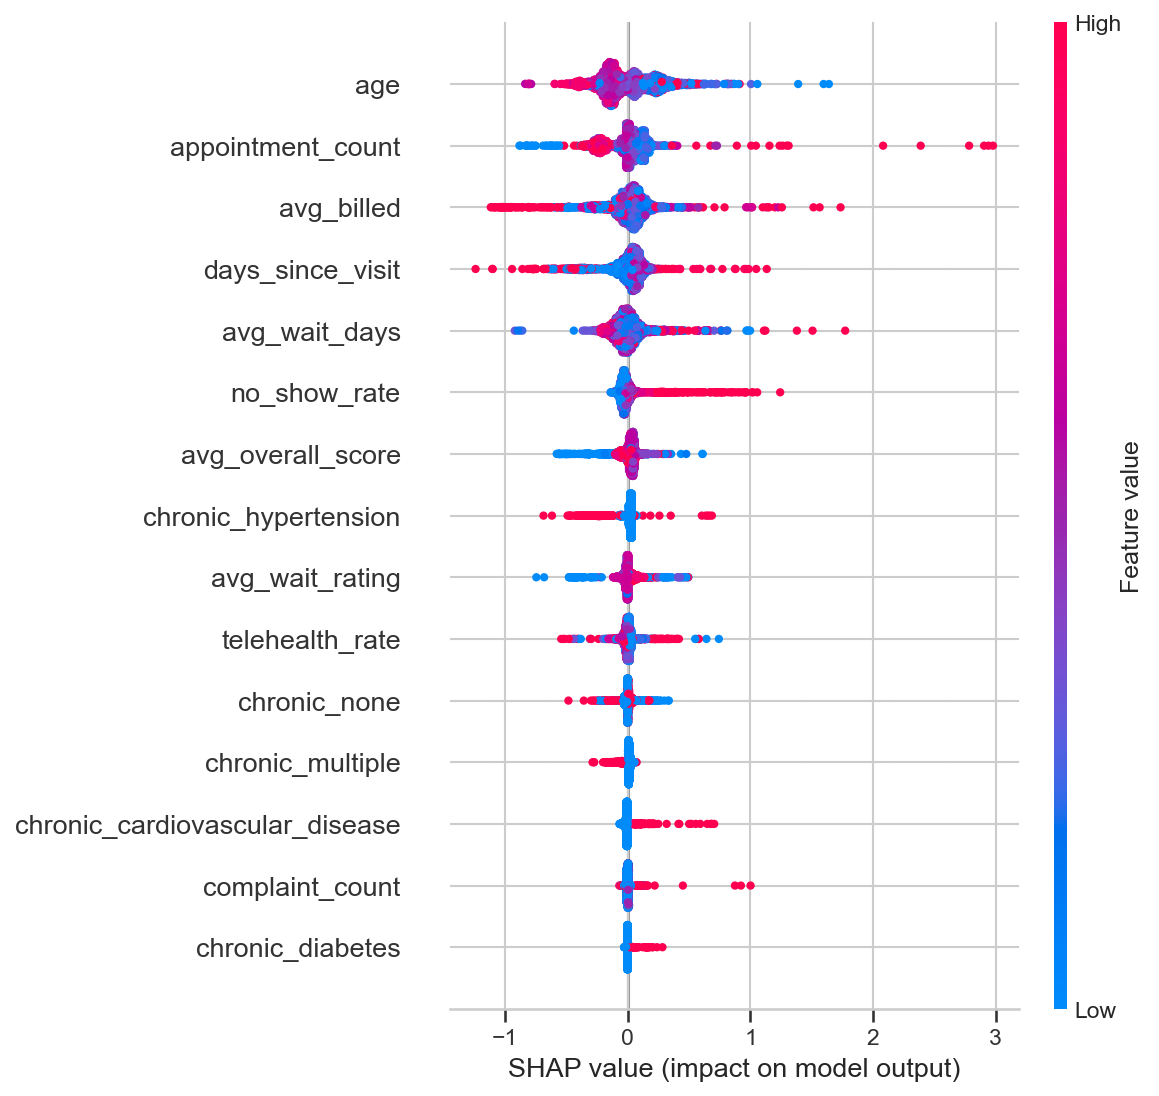

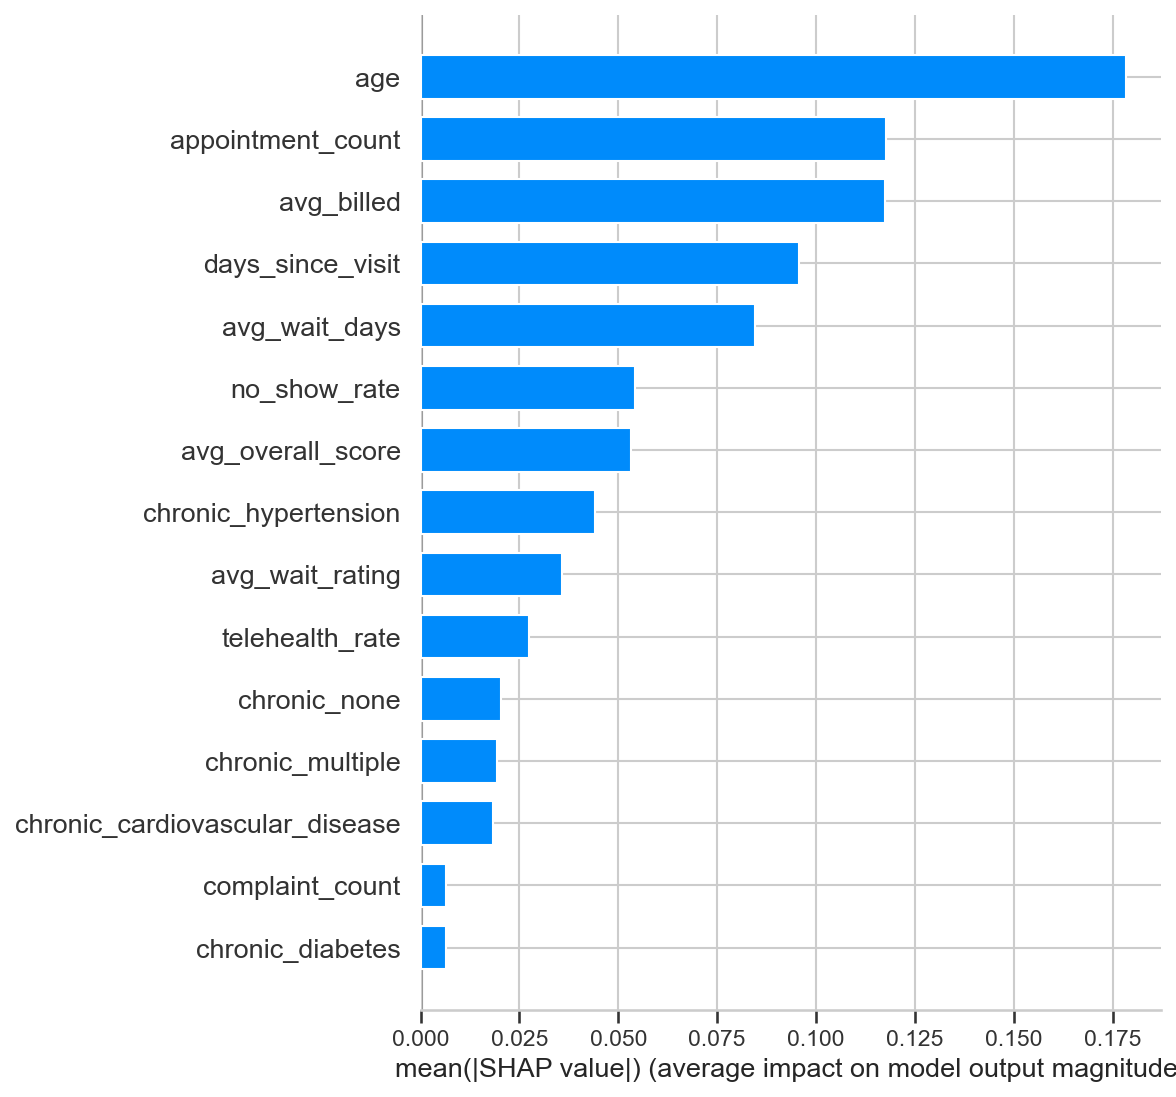

In [32]:
from src.churn_model import explain_with_shap

shap_input = {
    'model':         gb_model,
    'feature_names': X.columns.tolist(),
}

shap_result = explain_with_shap(
    result   = shap_input,
    features = feature_df,
    save_dir = REPORTS_DIR,
    top_n    = 15,
)

print('Top 15 features by mean |SHAP| value:')
print(shap_result['summary_df'].to_string(index=False))

# Display saved charts inline
from IPython.display import Image, display
import os
display(Image(os.path.join(REPORTS_DIR, 'shap_summary.png')))
display(Image(os.path.join(REPORTS_DIR, 'shap_importance_bar.png')))

Explaining prediction for: Ruby Williams (35y, QLD, private_fund)
Churn probability: 91.9%

Saved: ../reports/shap_patient_2575.png


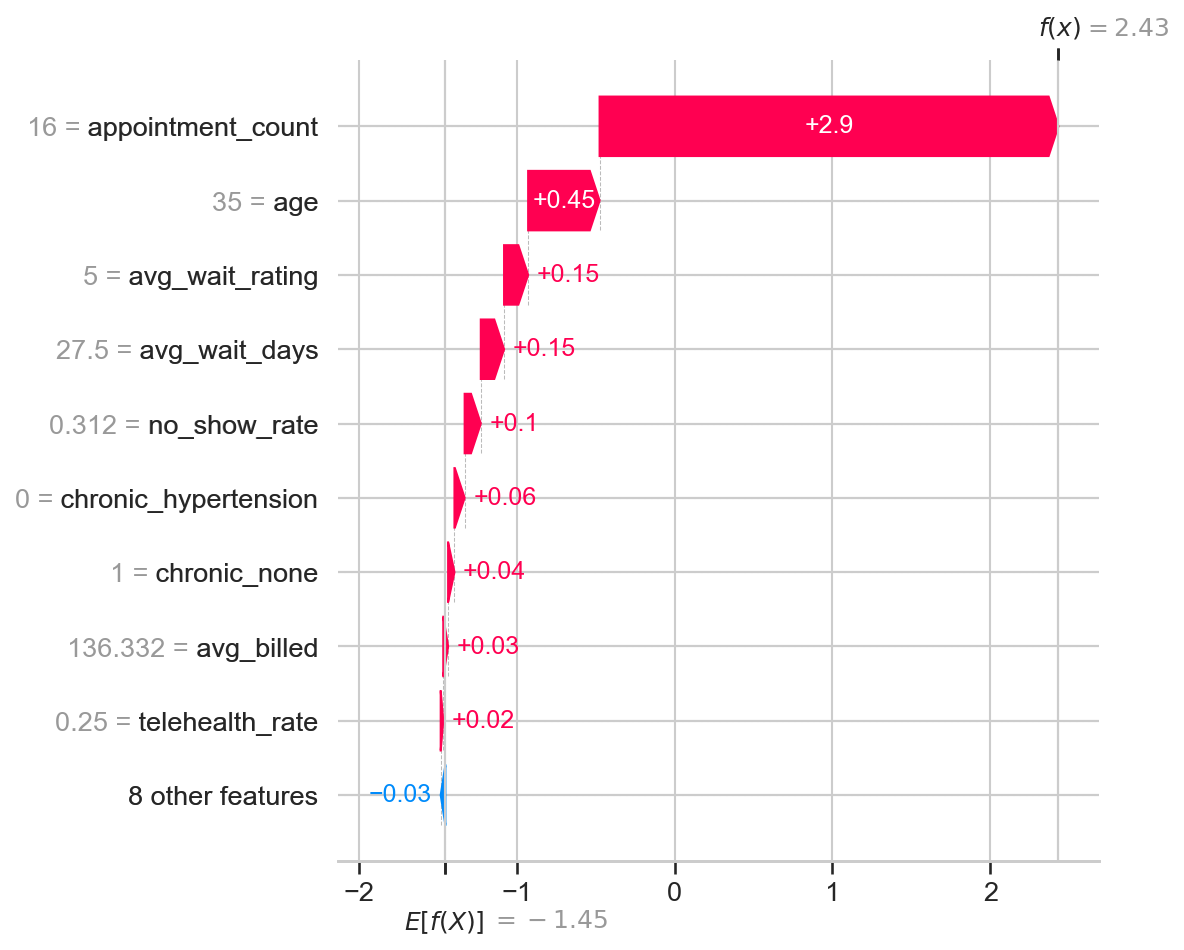

In [33]:
from src.churn_model import explain_single_patient

highest_risk_idx = scored_df['churn_probability'].idxmax()
patient_row = feature_df[feature_df['patient_id'] == scored_df.loc[highest_risk_idx, 'patient_id']]
patient_pos = feature_df.index.get_loc(patient_row.index[0])

patient_info = patients.loc[
    patients['patient_id'] == scored_df.loc[highest_risk_idx, 'patient_id'],
    ['full_name', 'state', 'insurance_type', 'age']
].iloc[0]

print(f'Explaining prediction for: {patient_info["full_name"]} '
      f'({patient_info["age"]}y, {patient_info["state"]}, {patient_info["insurance_type"]})')
print(f'Churn probability: {scored_df.loc[highest_risk_idx, "churn_probability"]:.1%}')
print()

explain_single_patient(
    shap_result   = shap_result,
    features      = feature_df,
    patient_index = patient_pos,
    save_dir      = REPORTS_DIR,
)

# Display waterfall chart inline
from IPython.display import Image, display
import os
display(Image(os.path.join(REPORTS_DIR, f'shap_patient_{patient_pos}.png')))